In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0,1,2"

In [2]:
import torch
import matplotlib.pyplot as plt
from custom_vision_transformer import vit_custom_16
from torchvision.models.feature_extraction import create_feature_extractor
import training_parameters as params
from training_utils import *

In [4]:
print("Number of visible GPUs :", torch.cuda.device_count())

gpu_idx = 1
torch.cuda.set_device(gpu_idx)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device :", device)
print("GPU visible :", torch.cuda.current_device())
print("GPU name :", torch.cuda.get_device_name(torch.cuda.current_device()))

Number of visible GPUs : 3
Device : cuda
GPU visible : 1
GPU name : NVIDIA GeForce RTX 2080


In [5]:
# --- load model ---
model = vit_custom_16(num_classes=params.num_classes, attention_bias=True).to(device)
model.load_state_dict(torch.load("./training_checkpoints/vit_custom_16_epoch_60.pth"))
model.eval();

Number of training samples: 9025
Number of validation samples: 3929
Input tensor shape: torch.Size([1, 3, 224, 224])


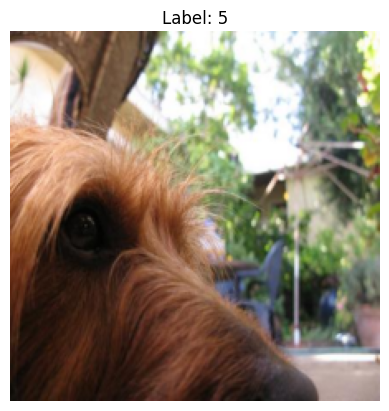

In [31]:
# --- load data ---
train_loader, val_loader, mask = get_data_loaders(params.batch_size, params.img_size, device)
mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

imgs, labels = next(iter(val_loader))
tensor = imgs[0].unsqueeze(0).to(device)  # add batch dimension and move to device

print("Input tensor shape:", tensor.shape)
plt.imshow((imgs[0] * std + mean).permute(1, 2, 0).numpy())
plt.title(f"Label: {labels[0].item()}")
plt.axis("off")
plt.show()

In [32]:
activations = {
    "b": {},
    "attn": {}
}

# --- Fonctions hook ---
def make_b_hook(name):
    def hook(module, input, output):
        activations["b"][name] = output.detach()
    return hook

def make_attn_hook(name):
    def hook(module, input, output):
        out, attn = output
        activations["attn"][name] = attn.detach()
    return hook

# --- Nettoyer tous les hooks existants sur tous les modules ---
for module in model.modules():
    module._forward_hooks.clear()

# --- Ajouter les hooks ---
for name, module in model.named_modules():
    if name.endswith(".self_attention.b"):
        module.register_forward_hook(make_b_hook(name))
    elif name.endswith(".self_attention"):
        module.register_forward_hook(make_attn_hook(name))

In [33]:
_ = model(tensor.to(device))

In [34]:
for k, v in activations["attn"].items():
    print(k, v.shape)

for k, v in activations["b"].items():
    print(k, v.shape)

encoder.layers.encoder_layer_0.self_attention torch.Size([1, 6, 197, 197])
encoder.layers.encoder_layer_1.self_attention torch.Size([1, 6, 197, 197])
encoder.layers.encoder_layer_2.self_attention torch.Size([1, 6, 197, 197])
encoder.layers.encoder_layer_3.self_attention torch.Size([1, 6, 197, 197])
encoder.layers.encoder_layer_4.self_attention torch.Size([1, 6, 197, 197])
encoder.layers.encoder_layer_5.self_attention torch.Size([1, 6, 197, 197])
encoder.layers.encoder_layer_0.self_attention.b torch.Size([1, 197, 6])
encoder.layers.encoder_layer_1.self_attention.b torch.Size([1, 197, 6])
encoder.layers.encoder_layer_2.self_attention.b torch.Size([1, 197, 6])
encoder.layers.encoder_layer_3.self_attention.b torch.Size([1, 197, 6])
encoder.layers.encoder_layer_4.self_attention.b torch.Size([1, 197, 6])
encoder.layers.encoder_layer_5.self_attention.b torch.Size([1, 197, 6])


In [35]:
attention_list = [v for k, v in activations["attn"].items()]
b_list = [v for k, v in activations["b"].items()]

In [36]:
# --- attention map of all layers averaged across heads ---
attentions_avg = [attn.mean(dim=1) for attn in attention_list]  # average over heads
for i in range(6):
    plt.imshow(attentions_avg[i][0].cpu())
    plt.savefig(f"attention_maps/attention_maps_imgs/attention_map_{i}")
    plt.close()

In [37]:
num_layer = 3
attention_at_layer = attention_list[num_layer][0]
b_at_layer = b_list[num_layer][0]

In [38]:
# --- attention map of all heads from layer num_layer --- (only works if average_attn_weights=False in new_forward)
for i in range(6):
    plt.imshow(attention_at_layer[i,:,:].cpu())
    plt.savefig(f"attention_maps/attention_maps_all_heads_layer{num_layer}/attention_map_{i}")
    plt.close()

In [39]:
# --- attention bias map of all heads from layer num_layer ---
for head in range(b_at_layer.shape[-1]):
    tensor = b_at_layer[:, head].view(1, -1)
    tensor = torch.softmax(tensor, dim=-1)
    img = tensor.repeat(197, 1).cpu().numpy()
    plt.imshow(img)
    plt.savefig(f"attention_maps/attention_biases_all_heads_layer{num_layer}/bias_map_{head}")
    plt.close()

In [40]:
print(b_at_layer.shape)
print(attention_at_layer.shape)

torch.Size([197, 6])
torch.Size([6, 197, 197])


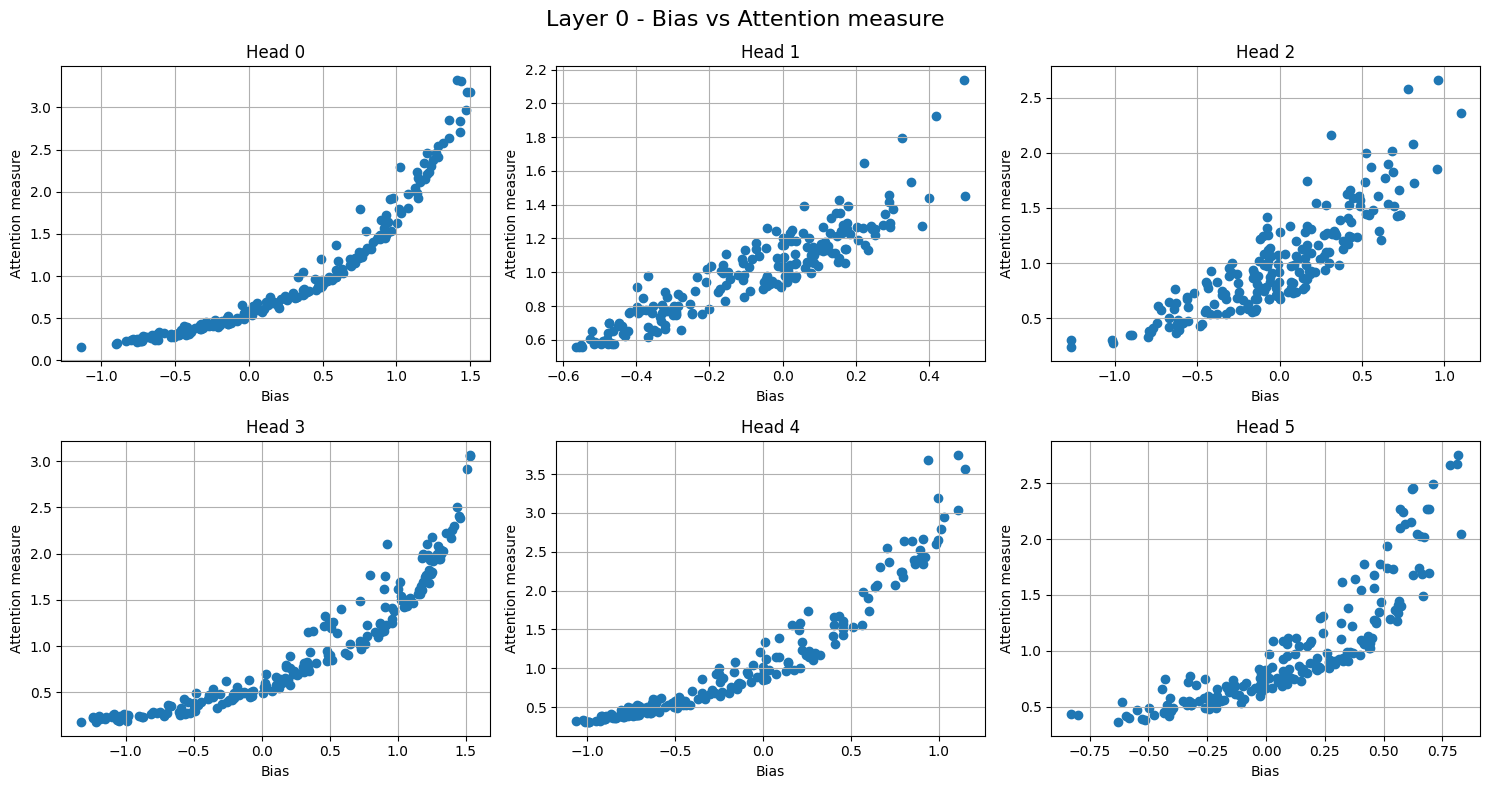

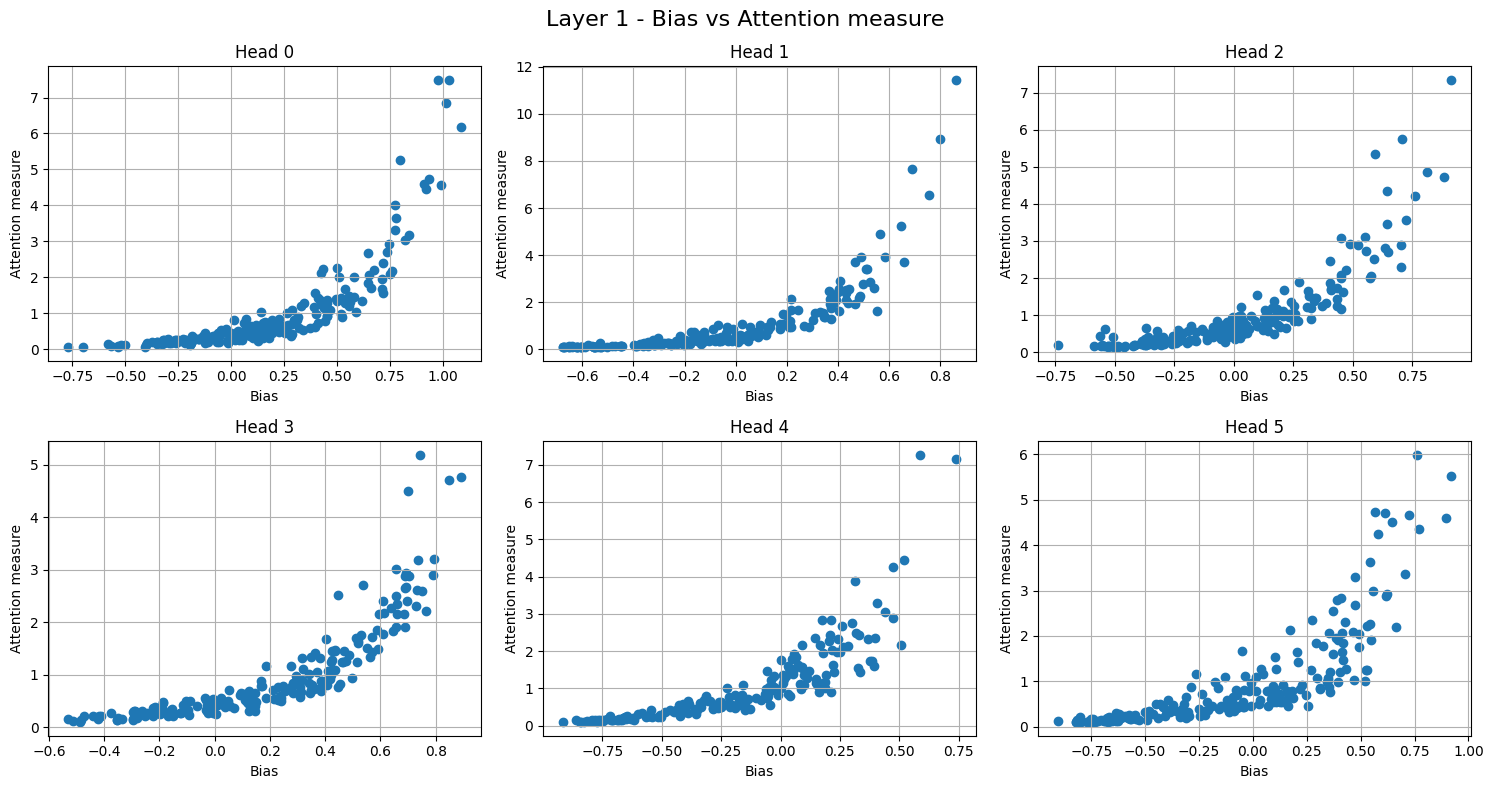

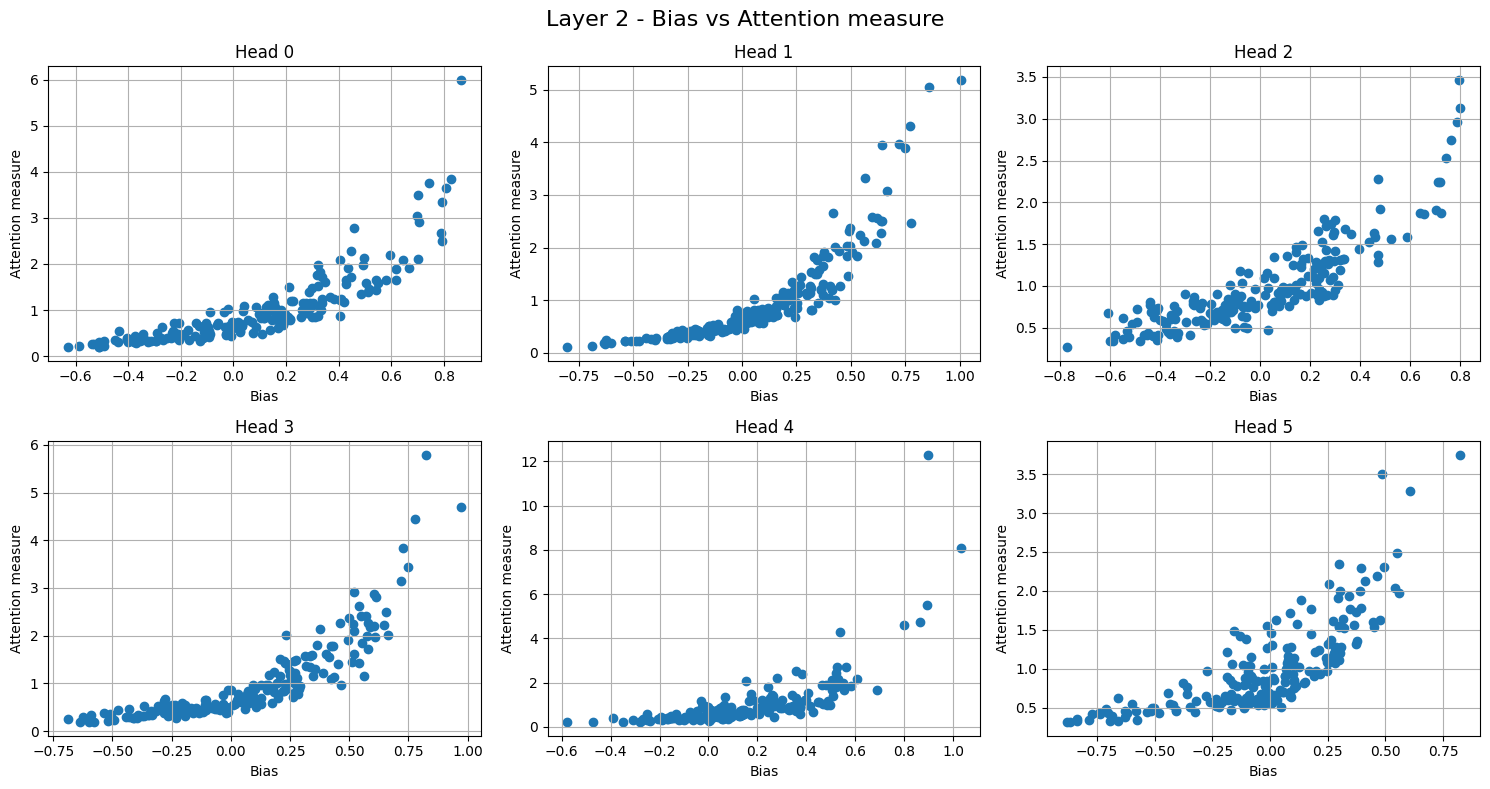

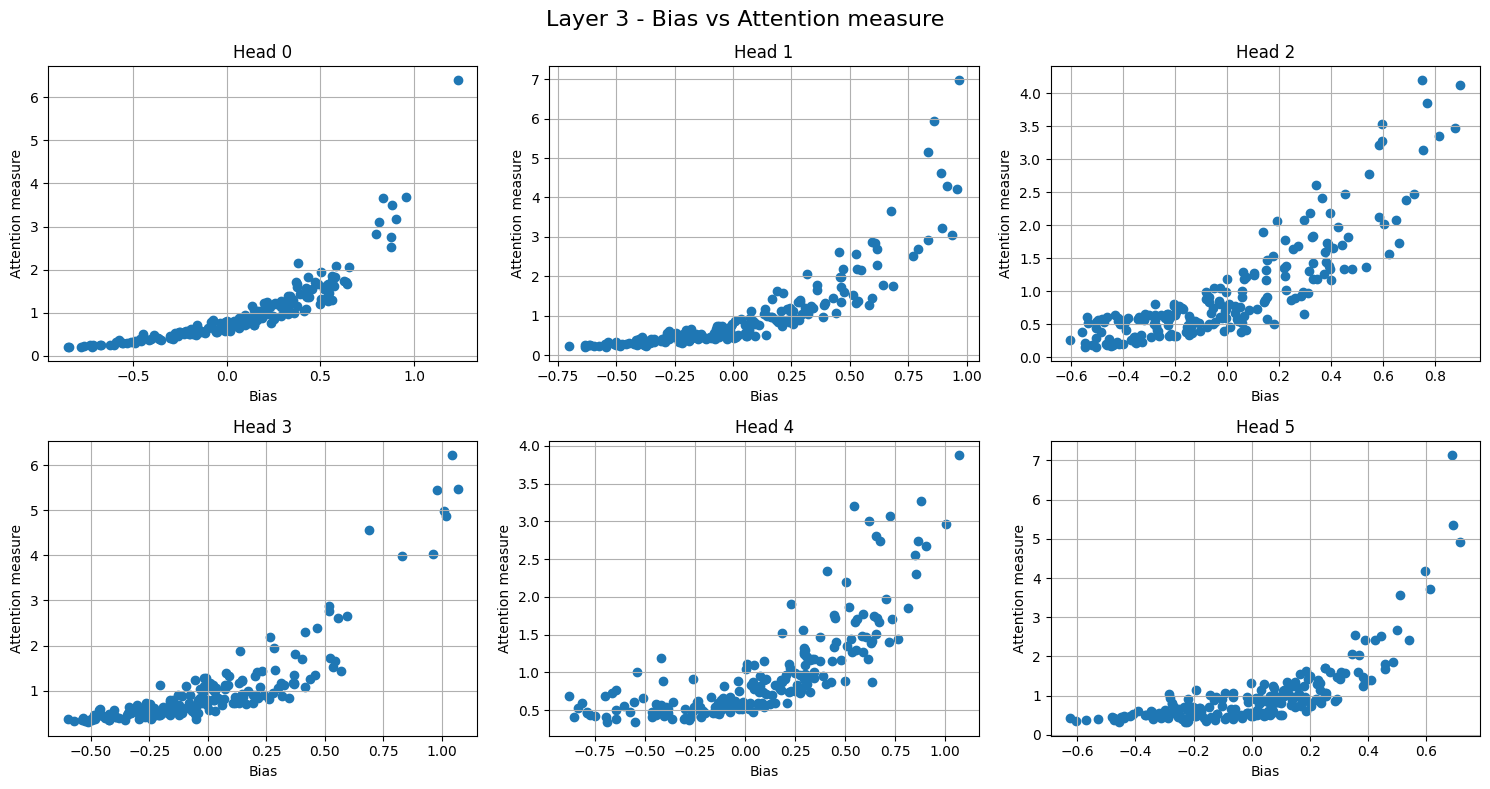

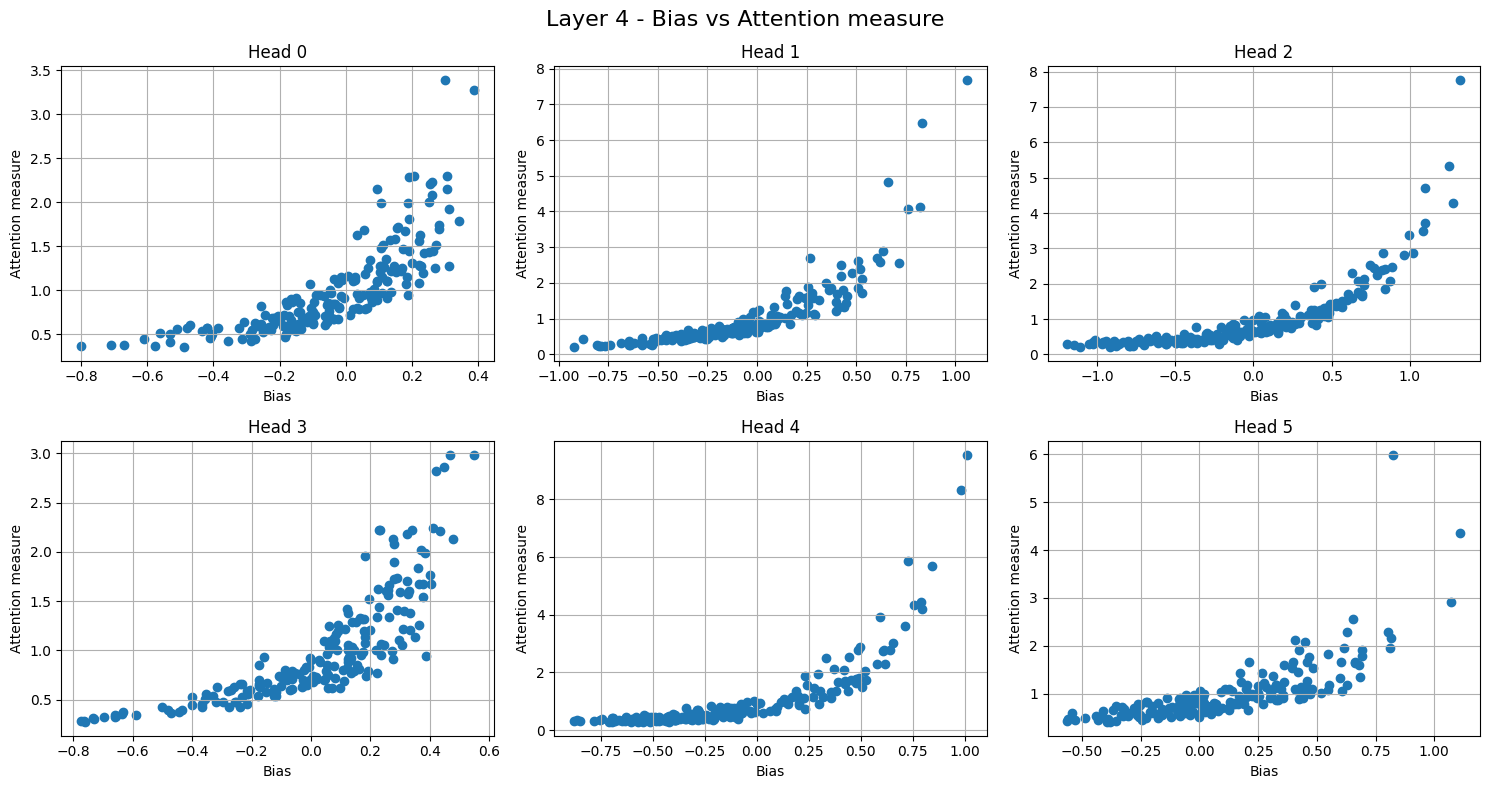

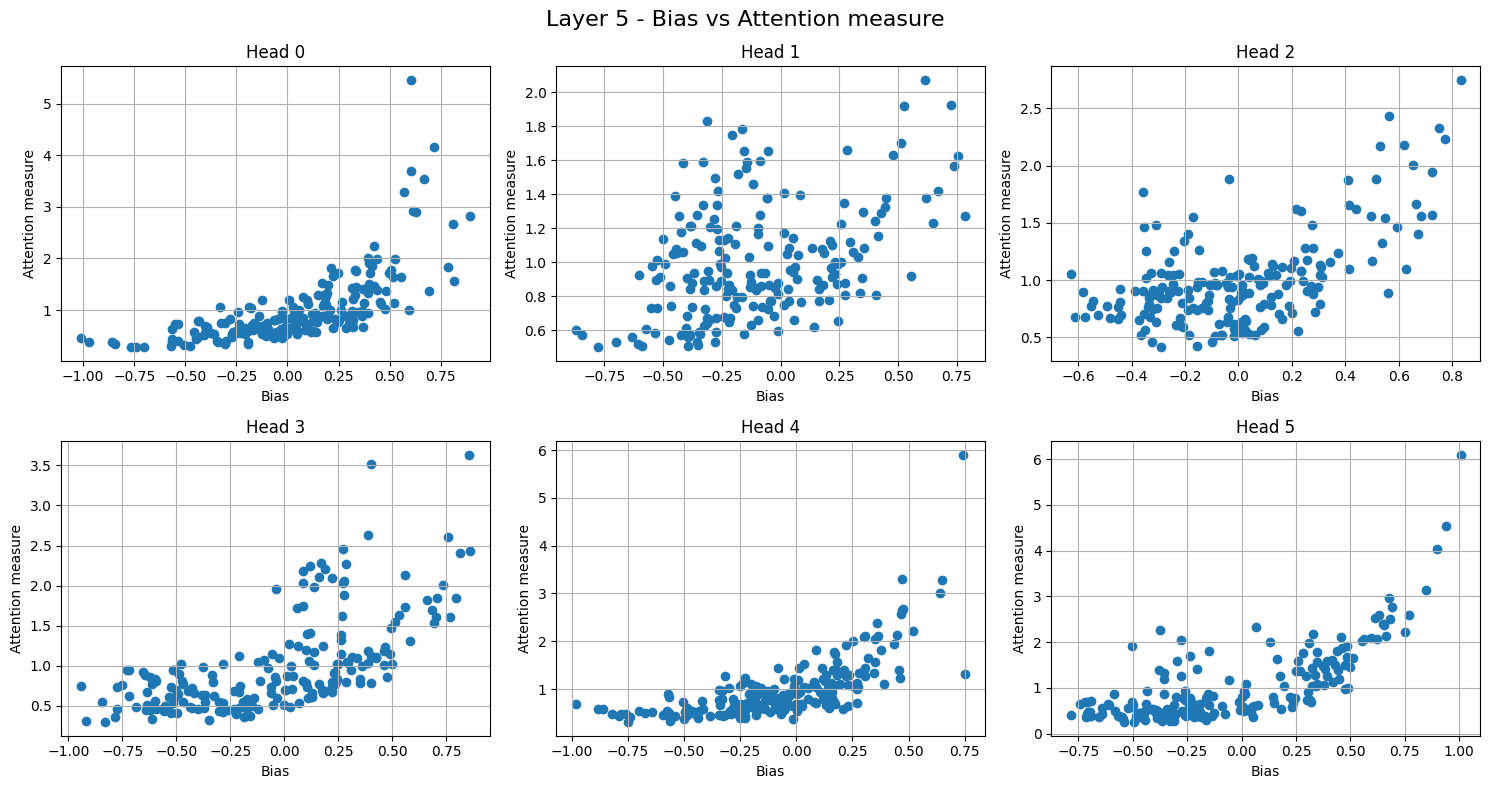

In [41]:
for i in range(6):
    num_layer = i
    attention_at_layer = attention_list[num_layer][0]
    b_at_layer = b_list[num_layer][0]

    n_heads = attention_at_layer.shape[0]  # nombre de têtes
    rows, cols = 2, 3  # grille 2x3

    plt.figure(figsize=(15, 8))  # taille globale de la figure
    plt.suptitle(f"Layer {num_layer} - Bias vs Attention measure", fontsize=16)

    for head in range(n_heads):
        b_head = b_at_layer[:, head]
        attention_map_head = attention_at_layer[head, :, :]
        attention_measure_head = attention_map_head.sum(dim=0)  # somme des poids d'attention pour chaque token

        plt.subplot(rows, cols, head + 1)  # position dans la grille
        plt.scatter(b_head.cpu(), attention_measure_head.cpu())
        plt.title(f"Head {head}")
        plt.xlabel("Bias")
        plt.ylabel("Attention measure")
        plt.grid(True)

    plt.tight_layout()  # ajuste les sous-figures pour éviter le chevauchement
    plt.show()